# EDA and preprocessing

In [2]:
import csv
import math
import os
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [5]:
RESULTS_FILE = "results.csv"

if not os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Approach", "CV", "CV STD", "LB", "Date"])

In [6]:
init_data = pd.read_csv("train.csv")
init_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check null values

In [7]:
for col in init_data.columns:
    print(col, init_data[col].isna().sum())

print()
print(init_data["Cabin"].isna().sum() / init_data.shape[0])
print(init_data["Age"].isna().sum() / init_data.shape[0])
print(init_data["Embarked"].isna().sum() / init_data.shape[0])

PassengerId 0
Survived 0
Pclass 0
Name 0
Sex 0
Age 177
SibSp 0
Parch 0
Ticket 0
Fare 0
Cabin 687
Embarked 2

0.7710437710437711
0.19865319865319866
0.002244668911335578


- 77% passengers without a cabin
- PassengerId doesn't affect result
- Ticket is a random string

Therefore, drop these columns

In [8]:
data = init_data.drop(columns=["PassengerId", "Cabin", "Ticket"])

In [9]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [10]:
def plot_counts(data, features, target="Survived", cols=2):
    n = len(features)
    rows = math.ceil(n / cols)

    _, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        df = data.groupby([feature, target])[target].count().reset_index(name="count")
        sns.barplot(data=df, x=feature, y="count", hue=target, ax=axes[idx])
        axes[idx].set_title(f"{feature} → {target}")
        axes[idx].tick_params(axis="x", rotation=30)

    # hide empty cells, if there are less features than 
    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

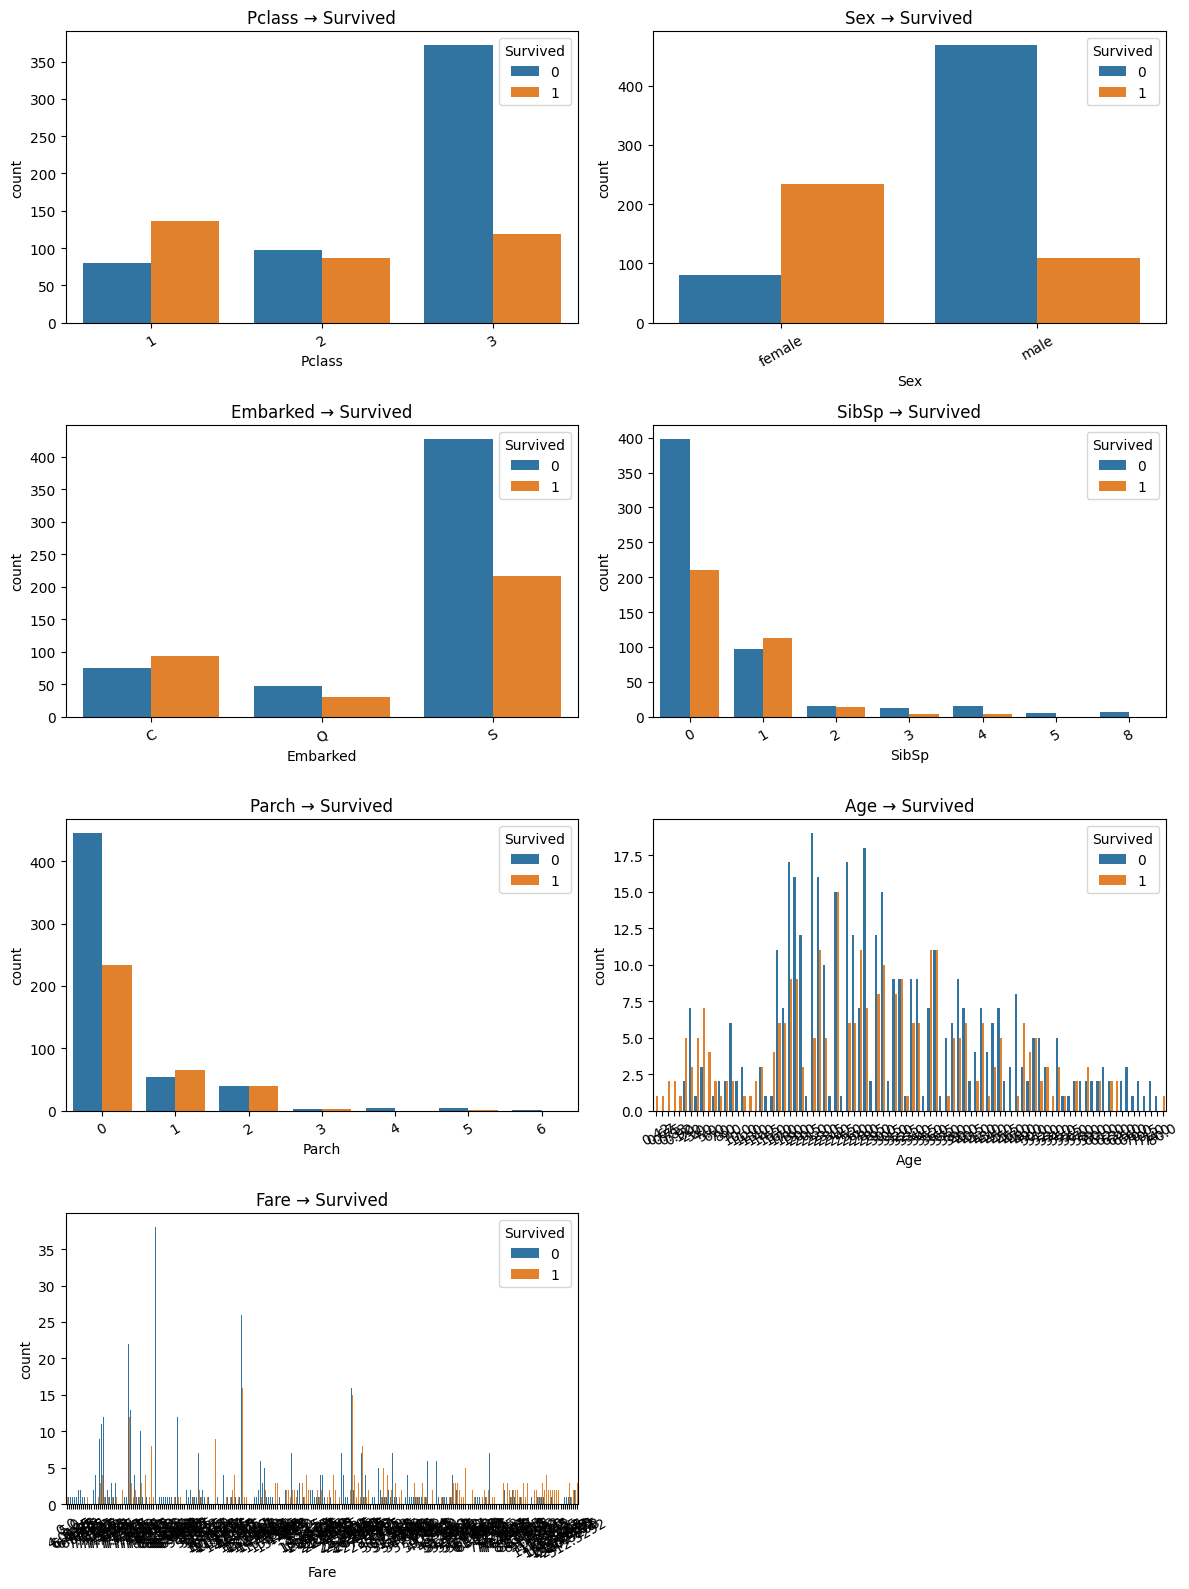

In [11]:
features = ["Pclass", "Sex", "Embarked", "SibSp", "Parch", "Age", "Fare"]

plot_counts(data, features)

- 3 class sucks
- women...
- embarked, parch, sibsp need more research
- age and fares have too many different fares => need to treat them as intervals

Age and fare are continuous features => convert them into ordinal

### Age

In [12]:
print("Oldest Passenger was of:", data["Age"].max(), "Years")
print("Youngest Passenger was of:", data["Age"].min(), "Years")
print("Average Age on the ship:", data["Age"].mean(), "Years")

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


Age STD is quite high, so just fill na with it is not appropriate
Idea: use salutations such as mrs. mr. etc. for sophisticated age processing [https://www.kaggle.com/code/ash316/eda-to-prediction-dietanic#Age--%3E-Continous-Feature]


In [13]:
data["Salut"] = data["Name"].str.extract(r"([A-Za-z]+)\.")

Explore salut-sex matching

In [14]:
pd.crosstab(data.Salut, data.Sex).T.style.background_gradient()


Salut,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


Convert salutations it to Master (40 is enough), Mr, Mrs, Miss

In [15]:
mapping = dict(
    zip(
        "Capt	Col	Countess	Don	Dr	Jonkheer	Lady	Major	Mlle	Mme	Ms	Rev	Sir".split(),
        [
            "Mr",
            "Mr",
            "Mrs",
            "Mr",
            "Mr",
            "Mr",
            "Mrs",
            "Mr",
            "Miss",
            "Miss",
            "Miss",
            "Mr",
            "Mr",
        ],
    )
)

data["Salut"] = data["Salut"].replace(mapping)

In [16]:
age_map = data.groupby("Salut")["Age"].mean().to_dict()
age_map

{'Master': 4.574166666666667,
 'Miss': 21.86,
 'Mr': 33.02272727272727,
 'Mrs': 35.981818181818184}

Fill missing age with its corresponding mean

In [17]:
data["Age"] = data["Age"].fillna(data["Salut"].map(age_map)).round()

In [18]:
data.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    22.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

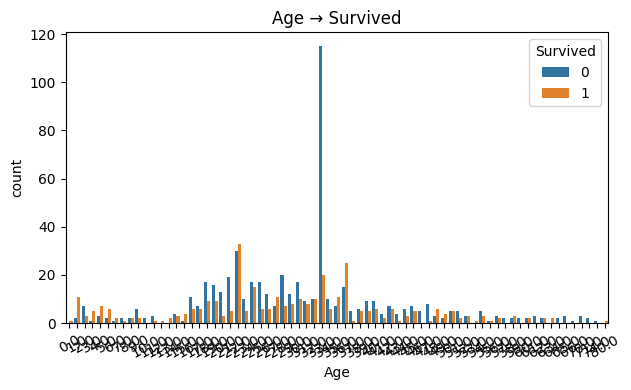

In [19]:
plot_counts(data, ["Age"], target="Survived", cols=2)

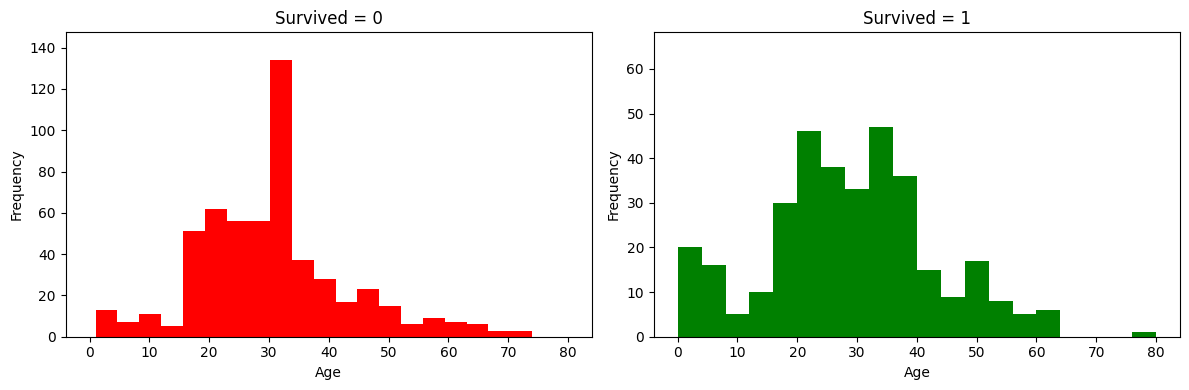

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=False)

for val, ax, color in zip([0, 1], axes, ["red", "green"]):
    sub = data.loc[data["Survived"] == val, "Age"]
    ax.hist(sub, bins=20, color=color)
    ax.set_title(f"Survived = {val}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")
    ax.set_ylim(0, sub.value_counts(bins=20).max() * 1.1)  # auto-scale

plt.tight_layout()
plt.show()

- outlier at age 30-35 who isn't survived probably due to age processing
- in general distribution are alike

### Embarked

In [21]:
data[data["Embarked"] == "S"].shape[0] / data.shape[0]

0.7227833894500562

In [22]:
data["Embarked"] = data["Embarked"].fillna("S")

There were 2 nans in Embarked column, fill them as "S" because the vast majority of passengers were embarked there.

### Correlation between the features

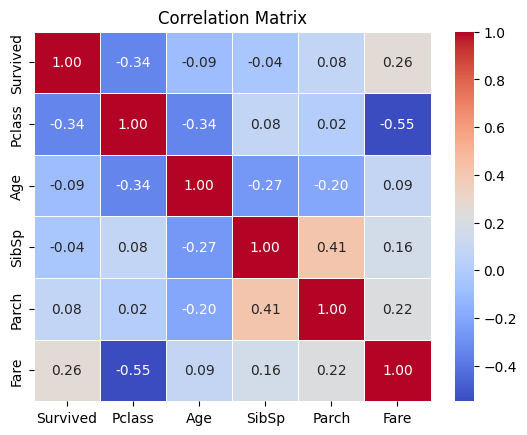

In [23]:
corr = data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,  # show numbers
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Matrix")
plt.show()

- parch and sibsp are correlated pretty much, so maybe there is some redundancy in it
- the rest features are not so correlated, (fare => survided and fare => parch are somewhat correlated)

## Feature engineering

1. Age and fare need to be converted into ordinal values

In [24]:
data["Fare_band"] = pd.qcut(data["Fare"], 5)
data.groupby(["Fare_band"])["Survived"].mean().to_frame()

,Survived
Fare_band,
"(-0.001, 7.854]",0.217877
"(7.854, 10.5]",0.201087
"(10.5, 21.679]",0.424419
"(21.679, 39.688]",0.444444
"(39.688, 512.329]",0.642045


In [25]:
data["Age_band"] = pd.qcut(data["Age"], 5)
data.groupby(["Age_band"])["Survived"].mean().to_frame()

,Survived
Age_band,
"(-0.001, 20.0]",0.456522
"(20.0, 26.0]",0.400000
"(26.0, 33.0]",0.280303
"(33.0, 38.0]",0.527473
"(38.0, 80.0]",0.372881


In [26]:
data["Fare_band"] = pd.qcut(data["Fare"], q=5, labels=False)
data["Age_band"] = pd.qcut(data["Age"], q=5, labels=False)

In [27]:
data[["Fare", "Fare_band"]].head()

,Fare,Fare_band
0,7.2500,0
1,71.2833,4
2,7.9250,1
3,53.1000,4
4,8.0500,1


In [28]:
data[["Age", "Age_band"]].head()

,Age,Age_band
0,22.0,1
1,38.0,3
2,26.0,1
3,35.0,3
4,35.0,3


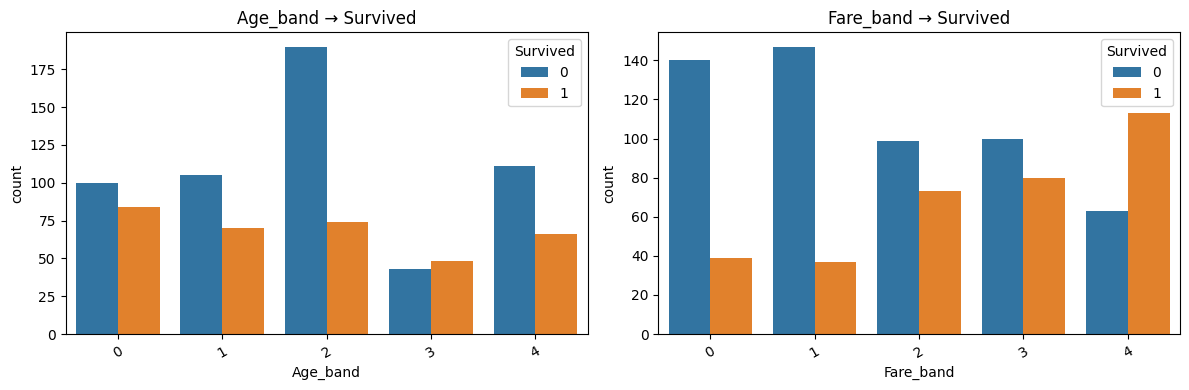

In [29]:
plot_counts(data, ["Age_band", "Fare_band"], target="Survived", cols=2)

2. Parch and sibSp are highly correlated and mean family size, so combining them sounds logical

In [30]:
data["Family_size"] = data["SibSp"] + data["Parch"]
data["Alone"] = (data["Family_size"] == 0).astype(int)

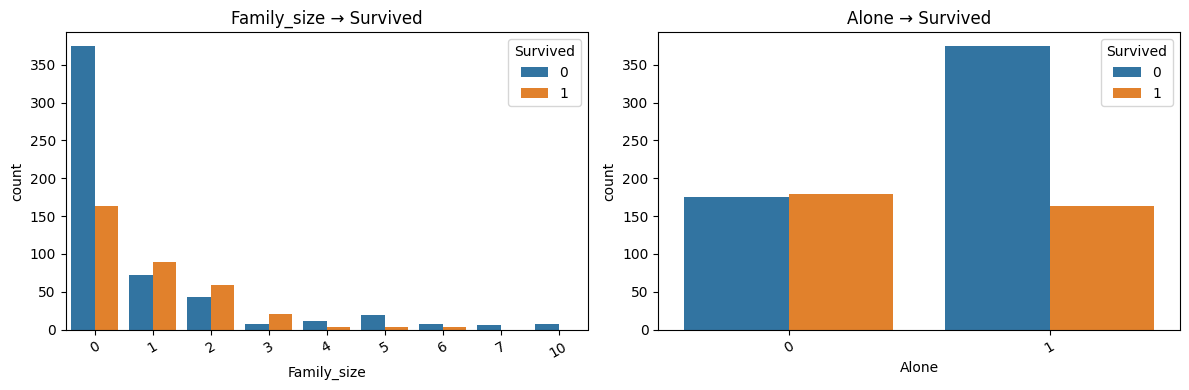

In [31]:
plot_counts(data, ["Family_size", "Alone"], target="Survived", cols=2)

The less passengers had people around him the more likely they weren't going to survive
Next convert categorial features to ordinal so model can process them better

In [32]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Salut,Fare_band,Age_band,Family_size,Alone
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr,0,1,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs,4,3,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss,1,1,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,4,3,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr,1,3,0,1


In [33]:
data["Salut"].value_counts()

Salut
Mr        538
Miss      186
Mrs       127
Master     40
Name: count, dtype: int64

In [34]:
data["Sex"] = data["Sex"].replace(["male", "female"], [0, 1]).astype(np.int64)
data["Embarked"] = data["Embarked"].replace(["S", "C", "Q"], [0, 1, 2]).astype(np.int64)
data["Salut"] = data["Salut"].replace(["Mr", "Mrs", "Miss", "Master"], [0, 1, 2, 3]).astype(np.int64)

Next drop redundant info

- name doesn't impact anything
- drop age because of age_band
- drop fare because of fare_band

For future experiments

In [35]:
extended_data = data.copy()

In [36]:
data.drop(["Name", "Age", "Fare"], axis=1, inplace=True)

In [37]:
data.head()

,Survived,Pclass,Sex,SibSp,Parch,Embarked,Salut,Fare_band,Age_band,Family_size,Alone
0,0,3,0,1,0,0,0,0,1,1,0
1,1,1,1,1,0,1,1,4,3,1,0
2,1,3,1,0,0,0,2,1,1,0,1
3,1,1,1,1,0,0,1,4,3,1,0
4,0,3,0,0,0,0,0,1,3,0,1


There are only numbers so data is ready

# Validation and learning

In [38]:
from datetime import datetime


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.base import is_regressor
from sklearn.decomposition import PCA

import catboost
import lightgbm
import xgboost

In [39]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Salut',
       'Fare_band', 'Age_band', 'Family_size', 'Alone'],
      dtype='str')

In [40]:
X = data[data.columns[1:]]
Y = data["Survived"]
skf = StratifiedKFold(n_splits=10, random_state=7, shuffle=True)

In [41]:
def log_experiment(approach: str, cv_scores, lb: float | None = None):
    cv_scores = np.array(cv_scores)

    row = [
        approach,
        float(cv_scores.mean()),
        float(cv_scores.std()),
        lb,
        datetime.now().strftime("%Y-%m-%d %H:%M"),
    ]

    with open(RESULTS_FILE, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(row)

In [42]:
X.dtypes

Pclass         int64
Sex            int64
SibSp          int64
Parch          int64
Embarked       int64
Salut          int64
Fare_band      int64
Age_band       int64
Family_size    int64
Alone          int64
dtype: object

In [43]:
X.head()

,Pclass,Sex,SibSp,Parch,Embarked,Salut,Fare_band,Age_band,Family_size,Alone
0,3,0,1,0,0,0,0,1,1,0
1,1,1,1,0,1,1,4,3,1,0
2,3,1,0,0,0,2,1,1,0,1
3,1,1,1,0,0,1,4,3,1,0
4,3,0,0,0,0,0,1,3,0,1


In [44]:
def train_models(models: list):
    for name, model, need_scaler, use_pca in models:
        print(f"Evaluating {name}...")
        scores = []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, Y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

            steps = []

            if need_scaler:
                steps.append(("scaler", StandardScaler()))

            if use_pca:
                steps.append(("pca", PCA(n_components=3, random_state=7)))

            steps.append(("model", model))

            pipeline = Pipeline(steps)
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            if is_regressor(model):
                y_pred_bin = np.round(y_pred).astype(int)
            else:
                y_pred_bin = y_pred

            score = accuracy_score(y_test, y_pred_bin)
            scores.append(score)

        mean_acc = float(np.mean(scores))
        std_acc = float(np.std(scores))
        print(f"Mean accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
        log_experiment(
            approach=name,
            cv_scores=scores,
            lb=None,
        )

In [45]:
models = [
    ("LinearRegression", LinearRegression(), True, False),
    ("LinearRegression_PCA3", LinearRegression(), True, True),
    ("LogReg_L1", LogisticRegression(l1_ratio=1.0, solver="saga", max_iter=1000), True, False),
    ("LogReg_L1_PCA3", LogisticRegression(l1_ratio=1.0, solver="saga", max_iter=1000), True, True),
    ("LogReg_L2", LogisticRegression(l1_ratio=0.0, max_iter=1000), True, False),
    ("LogReg_L2_PCA3", LogisticRegression(l1_ratio=0.0, max_iter=1000), True, True),
    ("LogReg_EN", LogisticRegression(l1_ratio=0.5, solver="saga", max_iter=1000), True, False),
    ("LogReg_EN_PCA3", LogisticRegression(l1_ratio=0.5, solver="saga", max_iter=1000), True, True),
    ("KNN_5", KNeighborsClassifier(), True, False),
    ("KNN_5_PCA3", KNeighborsClassifier(), True, True),
    ("KNN_10", KNeighborsClassifier(n_neighbors=10), True, False),
    ("KNN_10_PCA3", KNeighborsClassifier(n_neighbors=10), True, True),
    ("KNN_dist", KNeighborsClassifier(weights="distance"), True, False),
    ("KNN_dist_PCA3", KNeighborsClassifier(weights="distance"), True, True),
    ("KNN_manhattan", KNeighborsClassifier(metric="manhattan"), True, False),
    ("KNN_manhattan_PCA3", KNeighborsClassifier(metric="manhattan"), True, True),
    ("DT", DecisionTreeClassifier(), False, False),
    ("RF_100", RandomForestClassifier(), False, False),
    ("RF_200", RandomForestClassifier(n_estimators=200), False, False),
    ("RF_balanced", RandomForestClassifier(class_weight="balanced"), False, False),
    ("CatBoost", catboost.CatBoostClassifier(verbose=0), False, False),
    ("LGBM", lightgbm.LGBMClassifier(verbose=-1), False, False),
    ("XGB", xgboost.XGBClassifier(eval_metric="logloss"), False, False),
]

train_models(models)

Evaluating LinearRegression...
Mean accuracy: 0.8170 ± 0.0303
Evaluating LinearRegression_PCA3...
Mean accuracy: 0.8047 ± 0.0360
Evaluating LogReg_L1...
Mean accuracy: 0.8182 ± 0.0293
Evaluating LogReg_L1_PCA3...
Mean accuracy: 0.8069 ± 0.0297
Evaluating LogReg_L2...
Mean accuracy: 0.8193 ± 0.0305
Evaluating LogReg_L2_PCA3...
Mean accuracy: 0.8069 ± 0.0297
Evaluating LogReg_EN...
Mean accuracy: 0.8182 ± 0.0310
Evaluating LogReg_EN_PCA3...
Mean accuracy: 0.8069 ± 0.0297
Evaluating KNN_5...
Mean accuracy: 0.8137 ± 0.0249
Evaluating KNN_5_PCA3...
Mean accuracy: 0.8080 ± 0.0280
Evaluating KNN_10...
Mean accuracy: 0.8271 ± 0.0239
Evaluating KNN_10_PCA3...
Mean accuracy: 0.8069 ± 0.0299
Evaluating KNN_dist...
Mean accuracy: 0.8047 ± 0.0279
Evaluating KNN_dist_PCA3...
Mean accuracy: 0.8035 ± 0.0279
Evaluating KNN_manhattan...
Mean accuracy: 0.8092 ± 0.0263
Evaluating KNN_manhattan_PCA3...
Mean accuracy: 0.8047 ± 0.0309
Evaluating DT...
Mean accuracy: 0.7867 ± 0.0324
Evaluating RF_100...
Mean 

### Neural networks

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

Обучение одной эпохи

In [47]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)

### Models

In [48]:
class MLP_2layers(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [49]:
class MLP_4layers(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.ReLU(),
            nn.Linear(100, 200),
            nn.ReLU(),
            nn.Linear(200, 300),
            nn.ReLU(),
            nn.Linear(300, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [50]:
class MLP_3layers(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 200),
            nn.Sigmoid(),
            nn.Linear(200, 400),
            nn.LeakyReLU(),
            nn.Linear(400, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [51]:
class MLP_Batchnorm(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),
            nn.Linear(200, 300),
            nn.BatchNorm1d(300),
            nn.ReLU(),
            nn.Linear(300, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [52]:
class MLP_Dropout(nn.Module):
    def __init__(self, input_size: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(100, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(200, 300),
            nn.BatchNorm1d(300),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(300, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [53]:
model_configs = [
    {
        "name": "MLP_2layers",
        "model": MLP_2layers,
        "args": (X.shape[1],),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_4layers",
        "model": MLP_4layers,
        "args": (X.shape[1],),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_3layers",
        "model": MLP_3layers,
        "args": (X.shape[1],),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_Batchnorm",
        "model": MLP_Batchnorm,
        "args": (X.shape[1],),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_Dropout5",
        "model": MLP_Dropout,
        "args": (X.shape[1], 0.5),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_Dropout25",
        "model": MLP_Dropout,
        "args": (X.shape[1], 0.25),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_Dropout25_Adamax",
        "model": MLP_Dropout,
        "args": (X.shape[1], 0.25),
        "optimizer": optim.Adamax,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_Dropout25_Scheduler",
        "model": MLP_Dropout,
        "args": (X.shape[1], 0.25),
        "optimizer": optim.Adam,
        "scheduler": "cosine",
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "MLP_Dropout25_200epochs",
        "model": MLP_Dropout,
        "args": (X.shape[1], 0.25),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 200,
        "batch_size": 32,
    },
    {
        "name": "MLP_Dropout25_200epochs",
        "model": MLP_Dropout,
        "args": (X.shape[1], 0.25),
        "optimizer": optim.Adam,
        "scheduler": None,
        "epochs": 100,
        "batch_size": 32,
        "lr": 0.01,
    },
]

### Training and evaluating

In [54]:
def train_mlp(cfg, X, Y, skf, device):
    name = cfg["name"]
    model_cls = cfg["model"]
    args = cfg["args"]
    optimizer_cls = cfg["optimizer"]
    scheduler_type = cfg["scheduler"]
    num_epochs = cfg["epochs"]

    scores = []

    for train_idx, test_idx in skf.split(X, Y):
        X_train = X.iloc[train_idx].values.astype(np.float32)
        X_val = X.iloc[test_idx].values.astype(np.float32)
        y_train = Y.iloc[train_idx].values.astype(np.float32)
        y_val = Y.iloc[test_idx].values.astype(np.float32)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        X_train_t = torch.from_numpy(X_train)
        y_train_t = torch.from_numpy(y_train)
        X_val_t = torch.from_numpy(X_val)
        y_val_t = torch.from_numpy(y_val)

        train_loader = DataLoader(
            TensorDataset(X_train_t, y_train_t),
            batch_size=cfg["batch_size"],
            shuffle=True,
            drop_last=True,
        )

        model = model_cls(*args).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optimizer_cls(model.parameters(), lr=cfg["lr"])

        if scheduler_type == "cosine":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
        elif scheduler_type == "step":
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30)
        else:
            scheduler = None

        for epoch in range(num_epochs):
            train_one_epoch(model, train_loader, criterion, optimizer, device)
            if scheduler:
                scheduler.step()

        with torch.no_grad():
            logits = model(X_val_t.to(device))
            proba = torch.sigmoid(logits).cpu().numpy()
            y_pred = (proba >= 0.5).astype(int)

        scores.append(accuracy_score(y_val, y_pred))

    mean_acc = np.mean(scores)
    std_acc = np.std(scores)

    print(f"{name}: {mean_acc:.4f} ± {std_acc:.4f}")
    log_experiment(name, scores)

    return mean_acc, std_acc

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = X.shape[1]
learning_rate = 3e-4

for cfg in model_configs[-1:]:
    train_mlp(cfg, X, Y, skf, device)


MLP_Dropout25_200epochs: 0.8260 ± 0.0259


## Feature combinations

In [56]:
data = extended_data.copy()

In [57]:
data["Family"] = data["SibSp"] + data["Parch"]
data["Fare_per_person"] = data["Fare"] / (data["Family_size"] + 1)
data["Age*Class"] = data["Age"] * data["Pclass"]
data["Is_child"] = (data["Age"] < 12).astype(int)
data["Fare_log"] = np.log1p(data["Fare"])
data.drop(["Name"], axis=1, inplace=True)

In [58]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Salut', 'Fare_band', 'Age_band', 'Family_size', 'Alone',
       'Family', 'Fare_per_person', 'Age*Class', 'Is_child', 'Fare_log'],
      dtype='str')

In [59]:
X = data[data.columns[1:]]
Y = data["Survived"]
skf = StratifiedKFold(n_splits=10, random_state=7, shuffle=True)

In [60]:
models = [
    ("LinearRegressionExtendedFeatures", LinearRegression(), True, False),
    (
        "LogReg_L1ExtendedFeatures",
        LogisticRegression(l1_ratio=1.0, solver="saga", max_iter=1000),
        True,
        False,
    ),
    ("LogReg_L2ExtendedFeatures", LogisticRegression(l1_ratio=0.0, max_iter=1000), True, False),
    (
        "LogReg_ENExtendedFeatures",
        LogisticRegression(l1_ratio=0.5, solver="saga", max_iter=1000),
        True,
        False,
    ),
    ("KNN_5ExtendedFeatures", KNeighborsClassifier(), True, False),
    ("KNN_10ExtendedFeatures", KNeighborsClassifier(n_neighbors=10), True, False),
    ("KNN_distExtendedFeatures", KNeighborsClassifier(weights="distance"), True, False),
    ("KNN_manhattanExtendedFeatures", KNeighborsClassifier(metric="manhattan"), True, False),
    ("DTExtendedFeatures", DecisionTreeClassifier(), False, False),
    ("RF_100ExtendedFeatures", RandomForestClassifier(), False, False),
    ("RF_200ExtendedFeatures", RandomForestClassifier(n_estimators=200), False, False),
    ("RF_balancedExtendedFeatures", RandomForestClassifier(class_weight="balanced"), False, False),
    ("CatBoostExtendedFeatures", catboost.CatBoostClassifier(verbose=0), False, False),
    ("LGBMExtendedFeatures", lightgbm.LGBMClassifier(verbose=-1), False, False),
    ("XGBExtendedFeatures", xgboost.XGBClassifier(eval_metric="logloss"), False, False),
]

train_models(models)

Evaluating LinearRegressionExtendedFeatures...
Mean accuracy: 0.8103 ± 0.0341
Evaluating LogReg_L1ExtendedFeatures...
Mean accuracy: 0.8171 ± 0.0306
Evaluating LogReg_L2ExtendedFeatures...
Mean accuracy: 0.8159 ± 0.0319
Evaluating LogReg_ENExtendedFeatures...
Mean accuracy: 0.8171 ± 0.0306
Evaluating KNN_5ExtendedFeatures...
Mean accuracy: 0.8181 ± 0.0258
Evaluating KNN_10ExtendedFeatures...
Mean accuracy: 0.8114 ± 0.0214
Evaluating KNN_distExtendedFeatures...
Mean accuracy: 0.8047 ± 0.0212
Evaluating KNN_manhattanExtendedFeatures...
Mean accuracy: 0.8125 ± 0.0250
Evaluating DTExtendedFeatures...
Mean accuracy: 0.7867 ± 0.0487
Evaluating RF_100ExtendedFeatures...
Mean accuracy: 0.8204 ± 0.0204
Evaluating RF_200ExtendedFeatures...
Mean accuracy: 0.8181 ± 0.0319
Evaluating RF_balancedExtendedFeatures...
Mean accuracy: 0.8136 ± 0.0317
Evaluating CatBoostExtendedFeatures...
Mean accuracy: 0.8350 ± 0.0324
Evaluating LGBMExtendedFeatures...
Mean accuracy: 0.8215 ± 0.0297
Evaluating XGBExtend

In [3]:
results = pd.read_csv("results.csv")
results = results.sort_values("CV", ascending=False)
results = results.drop_duplicates(subset="Approach", keep="first")

display(results)

,Approach,CV,CV STD,LB,Date
235,Ensemble_Stack_Ridge_TOP4,0.839463,0.025354,NaN,2026-03-03 12:23
234,Ensemble_Stack_LogReg_TOP4,0.834969,0.025379,NaN,2026-03-03 12:21
36,CatBoostExtendedFeatures,0.834956,0.032401,NaN,2026-03-03 11:15
132,Ensemble_Averaging_TOP5,0.834956,0.028237,NaN,2026-03-03 11:50
74,CatBoost,0.831586,0.023867,NaN,2026-03-03 11:30
193,Ensemble_Voting_TOP4,0.831586,0.029110,NaN,2026-03-03 12:06
204,KNN_10,0.827116,0.023920,NaN,2026-03-03 12:15
217,MLP_Dropout25_200epochs,0.826017,0.025864,NaN,2026-03-03 12:17
191,XGBExtendedFeatures,0.823733,0.037140,NaN,2026-03-03 12:03
87,RF_100ExtendedFeatures,0.822634,0.029392,NaN,2026-03-03 11:31


## Ensembles

In [62]:
from sklearn.base import clone

In [63]:
best_models = [
    ("cat_ext", catboost.CatBoostClassifier(verbose=0, random_state=42)),
    ("cat", catboost.CatBoostClassifier(verbose=0, random_state=42)),
    ("knn10", KNeighborsClassifier(n_neighbors=10)),
    ("mlp", MLP_Dropout(input_size=X.shape[1], dropout=0.25)),
    ("xgb_ext", xgboost.XGBClassifier(eval_metric="logloss", random_state=42)),
]

In [64]:
def fit_mlp_once(model_cls, args, X_train, y_train, batch_size, lr, num_epochs, device):
    # scale → always per training set
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)

    X_train_t = torch.from_numpy(X_train)
    y_train_t = torch.from_numpy(y_train.astype(np.float32))

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, drop_last=True
    )

    model = model_cls(*args).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        train_one_epoch(model, train_loader, criterion, optimizer, device)

    return model, scaler

In [65]:
def eval_avg_ensemble(best_models, X, Y, skf):
    scores = []

    for train_idx, test_idx in skf.split(X, Y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

        probas = []

        for name, model in best_models:
            # Cat/LGBM/XGB/KNN
            if name != "mlp":
                m = clone(model)
                m.fit(X_train, y_train)
                proba = m.predict_proba(X_test)[:, 1]
                probas.append(proba)

            else:
                mlp, mlp_scaler = fit_mlp_once(
                    MLP_Dropout,
                    (X_train.shape[1], 0.25),
                    X_train.values,
                    y_train.values,
                    batch_size=32,
                    lr=learning_rate,
                    num_epochs=200,
                    device=device,
                )

                mlp.eval()

                X_test_scaled = mlp_scaler.transform(X_test.values).astype(np.float32)
                X_test_t = torch.from_numpy(X_test_scaled).to(device)

                with torch.no_grad():
                    logits = mlp(X_test_t)
                    proba = torch.sigmoid(logits).cpu().numpy().ravel()

                probas.append(proba)

        mean_proba = np.mean(probas, axis=0)
        y_pred = (mean_proba >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        scores.append(acc)

    print("AVG ensemble:", np.mean(scores), "±", np.std(scores))
    log_experiment("Ensemble_Averaging_TOP5", scores)

In [66]:
eval_avg_ensemble(best_models, X, Y, skf)

AVG ensemble: 0.8315855181023719 ± 0.028229366571103014


### Voting

In [67]:
from sklearn.ensemble import VotingClassifier

In [68]:
def evaluate_sklearn_model(name, model, X, y, skf):
    scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test, y_pred)
        scores.append(score)

    mean_acc = float(np.mean(scores))
    std_acc = float(np.std(scores))

    print(f"{name}: {mean_acc:.4f} ± {std_acc:.4f}")

    log_experiment(
        approach=name,
        cv_scores=scores,
        lb=None,
    )

    return scores

In [69]:


estimators: list[tuple[str, Any]] = [
    ("cat_ext", catboost.CatBoostClassifier(verbose=0)),
    ("cat", catboost.CatBoostClassifier(verbose=0)),
    ("knn10", KNeighborsClassifier(n_neighbors=10)),
    ("xgb_ext", xgboost.XGBClassifier(eval_metric="logloss")),
]

voting = VotingClassifier(
    estimators=estimators,
    voting="soft",
    n_jobs=4,
)

## Stacking

In [70]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier

estimators: list[tuple[str, Any]] = [
    ("cat_ext", catboost.CatBoostClassifier(verbose=0)),
    ("cat", catboost.CatBoostClassifier(verbose=0)),
    ("knn10", KNeighborsClassifier(n_neighbors=10)),
    ("xgb_ext", xgboost.XGBClassifier(eval_metric="logloss")),
]

In [71]:
stack_lr = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression(max_iter=2000), cv=5, n_jobs=4
)

evaluate_sklearn_model("Ensemble_Stack_LogReg_TOP4", stack_lr, X, Y, skf)

Ensemble_Stack_LogReg_TOP4: 0.8350 ± 0.0254


[0.8777777777777778,
 0.8651685393258427,
 0.8426966292134831,
 0.8089887640449438,
 0.8314606741573034,
 0.7865168539325843,
 0.8314606741573034,
 0.8202247191011236,
 0.8539325842696629,
 0.8314606741573034]

In [72]:
stack_ridge = StackingClassifier(
    estimators=estimators, final_estimator=RidgeClassifier(), cv=5, n_jobs=4
)

evaluate_sklearn_model("Ensemble_Stack_Ridge_TOP4", stack_ridge, X, Y, skf)

Ensemble_Stack_Ridge_TOP4: 0.8395 ± 0.0254


[0.8777777777777778,
 0.8539325842696629,
 0.8539325842696629,
 0.8314606741573034,
 0.8202247191011236,
 0.7865168539325843,
 0.8651685393258427,
 0.8202247191011236,
 0.8539325842696629,
 0.8314606741573034]

In [2]:
import pandas as pd

results = pd.read_csv("results.csv")
results = results.sort_values("CV", ascending=False)
results = results.drop_duplicates(subset="Approach", keep="first")

display(results)

,Approach,CV,CV STD,LB,Date
235,Ensemble_Stack_Ridge_TOP4,0.839463,0.025354,NaN,2026-03-03 12:23
234,Ensemble_Stack_LogReg_TOP4,0.834969,0.025379,NaN,2026-03-03 12:21
36,CatBoostExtendedFeatures,0.834956,0.032401,NaN,2026-03-03 11:15
132,Ensemble_Averaging_TOP5,0.834956,0.028237,NaN,2026-03-03 11:50
74,CatBoost,0.831586,0.023867,NaN,2026-03-03 11:30
193,Ensemble_Voting_TOP4,0.831586,0.029110,NaN,2026-03-03 12:06
204,KNN_10,0.827116,0.023920,NaN,2026-03-03 12:15
217,MLP_Dropout25_200epochs,0.826017,0.025864,NaN,2026-03-03 12:17
191,XGBExtendedFeatures,0.823733,0.037140,NaN,2026-03-03 12:03
87,RF_100ExtendedFeatures,0.822634,0.029392,NaN,2026-03-03 11:31


Therefore, the final solutions are Ensemble_Stack_Ridge, Ensemble_Stack_LogReg, Catboost